In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib as mpl
import pandas as pd

In [8]:
# baseline =  pd.read_csv("/Users/vishchaudhary/rl-repo/results/two-qubit gates/CNOT_baseline_2_2025-04-27_23-43-53/env_data.csv", header=0)
# Avg fidelity:  0.9710715910393275
# Avg reward:  8.202954719899443
# Average final fidelity over last 100 episodes 0.9683191
# Average final reward over last 100 episodes 8.102796190000001

# baseline = pd.read_csv("/Users/vishchaudhary/rl-repo/results/two-qubit gates/random_baseline_4haarNum_2025-04-29_19-59-24/env_data.csv", header=0)
# Avg fidelity:  0.7481829982614437
# Avg reward:  3.1326474872404253
# Average final fidelity over last 100 episodes 0.7508045100000001
# Average final reward over last 100 episodes 3.1776021800000005
# baseline = pd.read_csv("/Users/vishchaudhary/rl-repo/results/two-qubit gates/random_baseline_2haarNum_2025-04-29_20-04-22/env_data.csv", header=0)
baseline = pd.read_csv('/Users/vishchaudhary/rl-repo/results/two-qubit gates/CNOT_baseline_relaxation_2025-05-07_00-29-43/env_data.csv', header=0)

In [9]:
def plot_data(df, figure_title=" ", fid_line=None, reward_line=None):
    """ Currently works for constant episode_length """
    # ---------------------- Getting data from files  <--------------------------------------
    fidelities = np.array(df.iloc[:, 0])
    rewards = np.array(df.iloc[:, 1])
    episode_ids = np.array(df.iloc[:, -1])

    print("max fidelity: ", max(fidelities))
    print("max reward: ", max(rewards))
    # print("Avg fidelity: ", np.mean(fidelities))
    # print("Avg reward: ", np.mean(rewards))

    # --------> Get fidelity, infidelity, and reward from the last step of the episode <--------
    final_fidelity_per_episode = []
    final_infelity_per_episode = []
    sum_of_rewards_per_episode = []

    current_episode_id = episode_ids[0]
    current_fidelity = fidelities[0]
    current_reward_sum = rewards[0]
    for i in range(len(episode_ids)):
        if (episode_ids[i] != current_episode_id) or (i == len(episode_ids) - 1):
            final_fidelity_per_episode.append(current_fidelity)
            final_infelity_per_episode.append(1 - current_fidelity)
            sum_of_rewards_per_episode.append(current_reward_sum)
            current_reward_sum = 0
        current_episode_id = episode_ids[i]
        current_fidelity = fidelities[i]
        current_reward_sum += rewards[i]
    # ------------------------------------------------------------------------------------------

    # ----------------------> Moving average <--------------------------------------
    # Fidelity
    rolling_average_window = 100
    avg_final_fidelity_per_episode = []
    avg_final_infelity_per_episode = []
    avg_sum_of_rewards_per_episode = []
    for i in range(len(final_fidelity_per_episode)):
        start = i - rolling_average_window if (i - rolling_average_window) > 0 else 0
        avg_final_fidelity_per_episode.append(np.mean(final_fidelity_per_episode[start: i + 1]))
        avg_final_infelity_per_episode.append(np.mean(final_infelity_per_episode[start: i + 1]))
        avg_sum_of_rewards_per_episode.append(np.mean(sum_of_rewards_per_episode[start: i + 1]))

    # Round averages to prevent numerical error when plotting
    rounding_precision = 6
    avg_final_fidelity_per_episode = np.round(avg_final_fidelity_per_episode, rounding_precision)
    avg_final_infelity_per_episode = np.round(avg_final_infelity_per_episode, rounding_precision)
    avg_sum_of_rewards_per_episode = np.round(avg_sum_of_rewards_per_episode, rounding_precision)

    if len(avg_final_fidelity_per_episode) >= 100:
        print("Average final fidelity over last 100 episodes", np.mean(avg_final_fidelity_per_episode[-100:]))
    if len(avg_sum_of_rewards_per_episode) >= 100:
        print("Average final reward over last 100 episodes", np.mean(avg_sum_of_rewards_per_episode[-100:]))

    # -------------------------------> Plotting <-------------------------------------
    rcParams['font.family'] = 'serif'
    mpl.style.use('seaborn-v0_8')

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.suptitle(figure_title)
    fig.set_size_inches(10, 5)

    # ----> fidelity <----
    ax1.scatter(range(len(final_fidelity_per_episode)), final_fidelity_per_episode, color="b", s=10)
    ax1.scatter(range(len(avg_final_fidelity_per_episode)), avg_final_fidelity_per_episode, color="k", s=10)
    ax1.set_title("Fidelity")
    ax1.set_title("a)", loc='left', fontsize='medium')
    ax1.set_xlabel("Episodes")

    # ----> infidelity <----
    ax2.scatter(range(len(final_infelity_per_episode)), final_infelity_per_episode, color="r", s=10)
    ax2.scatter(range(len(avg_final_infelity_per_episode)), avg_final_infelity_per_episode, color="k", s=10)
    ax2.set_yscale("log")
    ax2.set_title("1 - Fidelity (log scale)")
    ax2.set_title("b)", loc='left', fontsize='medium')
    ax2.set_xlabel("Episodes")

    # ----> reward <----
    ax3.scatter(range(len(sum_of_rewards_per_episode)), sum_of_rewards_per_episode, color="g", s=10)
    ax3.scatter(range(len(avg_sum_of_rewards_per_episode)), avg_sum_of_rewards_per_episode, color="k", s=10)
    ax3.set_title("Sum of Rewards")
    ax3.set_title("c)", loc='left', fontsize='medium')
    ax3.set_xlabel("Episodes")

        # Horizontal threshold lines
    if fid_line is not None:
        ax1.axhline(fid_line, color="yellow", linestyle="--")
        ax2.axhline(1-fid_line, color="yellow", linestyle="--")
    if reward_line is not None:
        ax3.axhline(reward_line, color="yellow", linestyle="--")

    plt.tight_layout()
    plt.show()


In [10]:
def compare_histograms(df_base, df_run, bins_fid=100, bins_inf=50, last_n=5000):


    # Extract fidelities
    fid_base = df_base.iloc[:, 0].values
    fid_run = df_run.iloc[:, 0].values

    # Optionally use only the last_n entries from the run
    if last_n is not None:
        fid_run = fid_run[-last_n:]
        fid_base = fid_base[-last_n:]

    # Compute infidelities
    inf_base = 1 - fid_base
    inf_run = 1 - fid_run

    # Determine axis limits to shrink empty space
    min_fid = min(fid_base.min(), fid_run.min())
    max_fid = max(fid_base.max(), fid_run.max())
    min_inf = min(inf_base.min(), inf_run.min())
    max_inf = max(inf_base.max(), inf_run.max())

    # Exclude zeros for log binning
    inf_nonzero = np.concatenate([inf_base[inf_base > 0], inf_run[inf_run > 0]])
    min_inf_nonzero = inf_nonzero.min()
    # Log-spaced bins for infidelity
    log_bin_edges = np.logspace(np.log10(min_inf_nonzero), np.log10(max_inf), bins_inf + 1)

    # Compute common bin edges for fidelity (linear)
    bin_edges = np.linspace(0, 1, bins_fid + 1)

    # Compute histograms (counts) for fidelity
    counts_base_f, _ = np.histogram(fid_base, bins=bin_edges)
    counts_run_f, _  = np.histogram(fid_run, bins=bin_edges)
    perc_base_f = counts_base_f / counts_base_f.sum() * 100
    perc_run_f  = counts_run_f  / counts_run_f.sum()  * 100

    # Compute bar positions for fidelity
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]
    offset = width / 4

    # Compute histograms (counts) for infidelity
    counts_base_inf, _ = np.histogram(inf_base, bins=log_bin_edges)
    counts_run_inf,  _ = np.histogram(inf_run,  bins=log_bin_edges)

    perc_base_inf = counts_base_inf / counts_base_inf.sum() * 100
    perc_run_inf  = counts_run_inf  / counts_run_inf.sum()  * 100

    # Side-by-side bar positioning on log bins
    widths = log_bin_edges[1:] - log_bin_edges[:-1]
    width_frac = 0.4
    offset_frac = (1 - width_frac) / 2
    left_base = log_bin_edges[:-1] + widths * offset_frac
    left_run  = left_base + widths * width_frac
    bar_widths = widths * width_frac

    # ---- Fidelity (%) histogram ----
    fig_fid = plt.figure(figsize=(6, 5))
    ax_fid = fig_fid.add_subplot(1, 1, 1)
    ax_fid.bar(centers - offset, perc_base_f, width/2, color='red', alpha=0.7, label='Baseline')
    ax_fid.bar(centers + offset, perc_run_f,  width/2, color='green', alpha=0.7, label='Run')
    ax_fid.set_title(f'Fidelity Distribution Last {last_n} Episodes')
    ax_fid.set_xlabel('Fidelity')
    ax_fid.set_ylabel('Percentage (%)')
    ax_fid.set_xlim(min_fid, max_fid)
    ax_fid.legend()
    plt.tight_layout()
    plt.show()

    # ---- Infidelity (%) histogram (larger figure) ----
    fig_inf = plt.figure(figsize=(16, 6))
    ax_inf = fig_inf.add_subplot(1, 1, 1)
    ax_inf.bar(left_base, perc_base_inf,  bar_widths, color='red',   alpha=0.7, label='Baseline')
    ax_inf.bar(left_run,  perc_run_inf,   bar_widths, color='green', alpha=0.7, label='Run')
    ax_inf.set_title(f'Infidelity Distribution Last {last_n} Episodes')
    ax_inf.set_xlabel('1 - Fidelity (log scale)')
    ax_inf.set_ylabel('Percentage (%)')
    ax_inf.set_xscale('log')
    ax_inf.set_xlim(min_inf_nonzero, max_inf)
    ax_inf.legend()
    plt.tight_layout()
    plt.show()

max fidelity:  0.9914434885424196
max reward:  2.067703263772539
Average final fidelity over last 100 episodes 0.98542895
Average final reward over last 100 episodes 1.8488942899999998


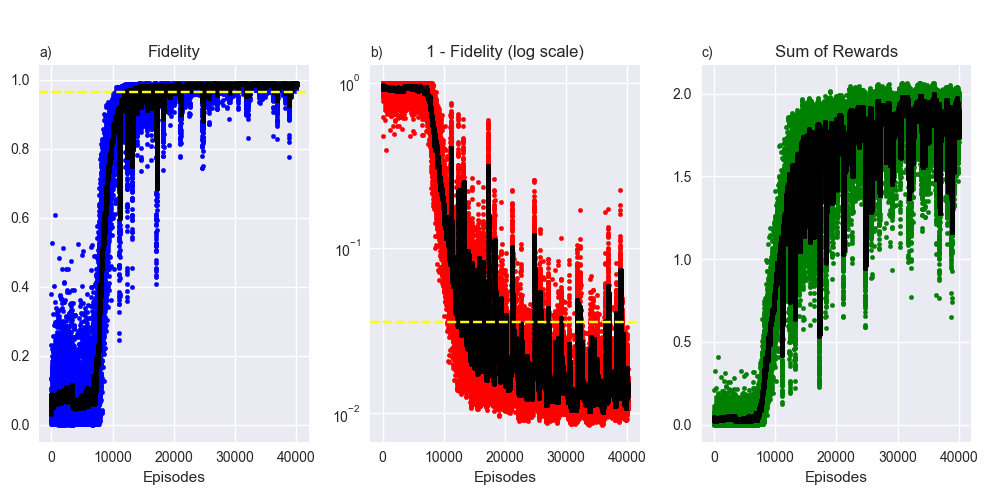

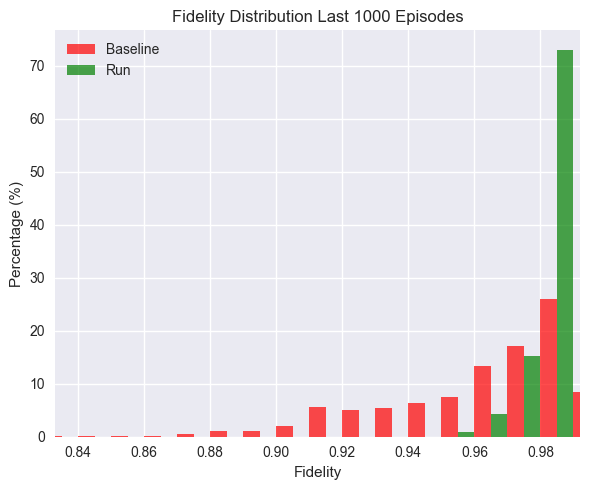

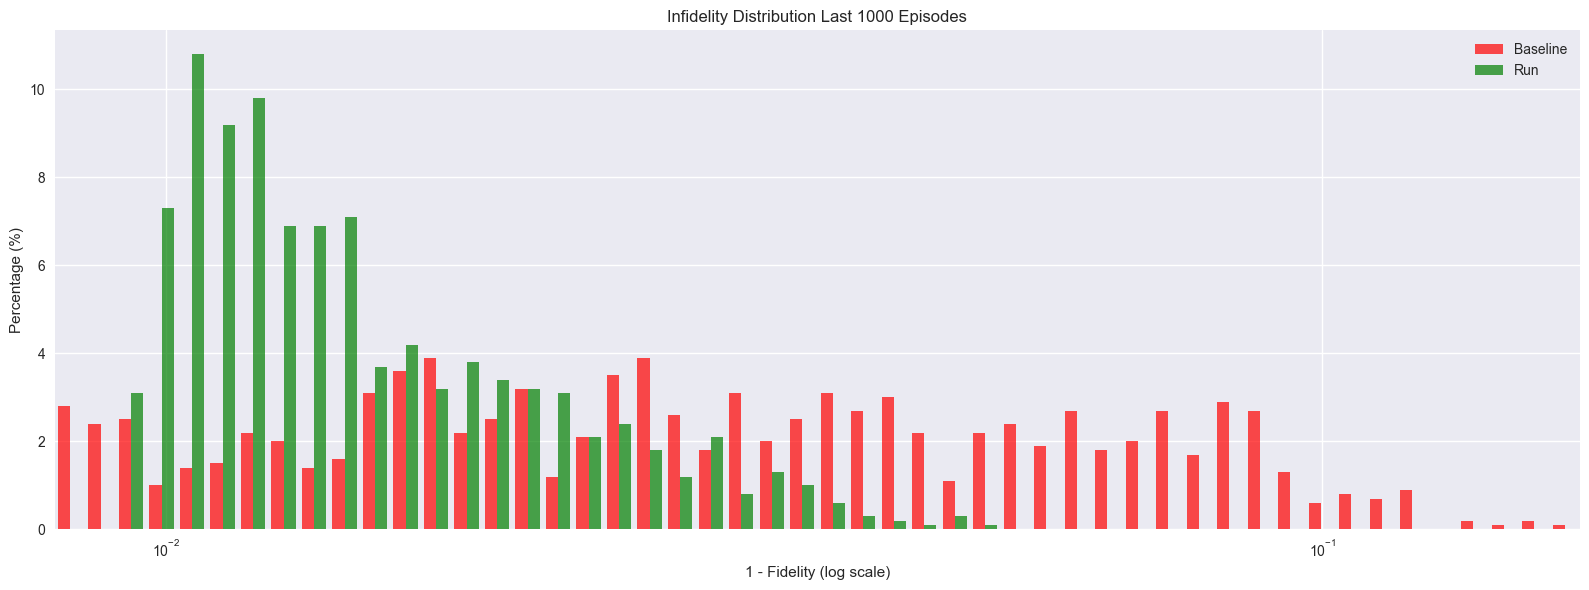

In [11]:
df = pd.read_csv("/Users/vishchaudhary/rl-repo/results/two-qubit gates/CNOT2025-05-15_05-02-22/env_data.csv", header=0)

plot_data(df, fid_line=0.9645082899999999)
compare_histograms(df_base=baseline, df_run = df, last_n=1000)

max fidelity:  0.9920047969137826
max reward:  6.178340188559917
Average final fidelity over last 100 episodes 0.9645082899999999
Average final reward over last 100 episodes 5.045723


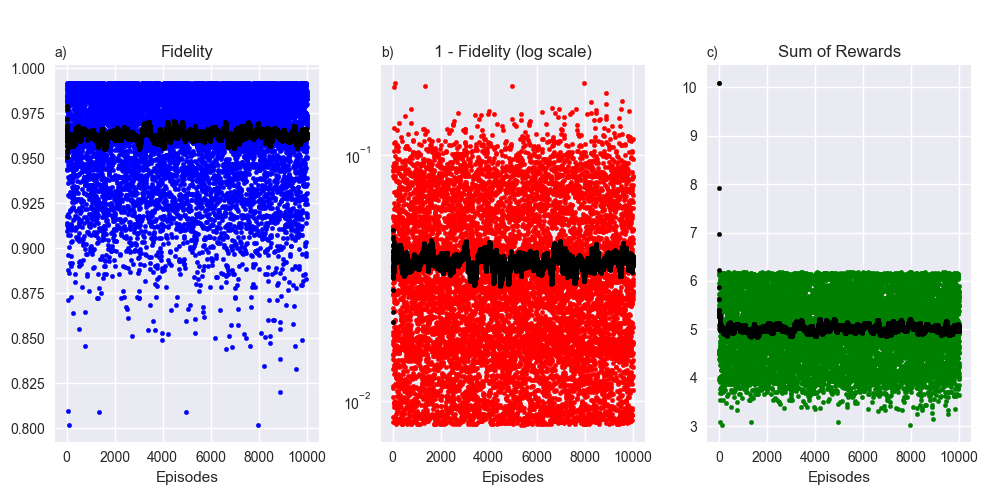

In [7]:
temp_df = pd.read_csv("/Users/vishchaudhary/rl-repo/results/two-qubit gates/CNOT_baseline_relaxation_2025-05-07_00-29-43/env_data.csv", header=0)
plot_data(temp_df)